## Outliers

#### When is outliers dangerous ?
Consider an column Age and it has an data of 300 , we know that this is not possible for human to live 300 and we can also not guess just from it either its 30 or 3 so here we remove the outlier<br><br>

Consider we predict the Marks of student based on study hours and there is an outlier where the student had studied for less hours and score more so here we cannot just remove the student from the data , so we add an new column named as IQ which justify that why the outlier is there <br><br>

So its very important to know when to remove outlier , when to keep it ,when to make changes in it .

#### Effect of outliers on ML algorithms

Outlier effecting this model <br>
Linear regression <br>
Logistic regression<br>
Deep learning too is effected by outliers<br><br>
So we can say that outlier effects the most when we use the alogorithm which is based on calculating the weights in them <br><br>

Tree based algorithm does not get effect that much from the outliers

#### How to treat Outliers ?

1. Trimming it (remove the outliers from the dataset)<br>
    Adv = its fast like just deleting the outlier<br>
    Dadv = if there are lots of outlier then the dataset will shrink<br>
2. capping (outlier can be on min side or max side , so we will put a limit on outlier means that above this is outlier or below this is outlier and what ever is beyond that points give that the value of that limit thery are near to )
3. Treat it like an Missing value and treat it accordingly<br>
4. Discritization ( here we create an bracket on numeric data like creating bins of the data like 90-100 so we will conside 90 and 100 as same , so if 100 was outlier it will be in that bin so it not outlier any more)<br><br>

3 and 4 are used less as compared to other 2 

#### how to detect outliers ?

1. Normal Distribution : if any observation is in range of (mean-3 std)< or (mean+ 3 std) > then we will consider it as outliers<br><br>
2. Skewed Distribution : here we use interquartile formula , here the if any number less than (Q1 - 1.5*IQR) and greater than (Q3 + 1.5 IQR) then we considet them as an outlier<br><br>
3. Percentile Based approach : here if the value if out of 97.5 or 99 percentile and out of 2 or 5 percentile then its all consider as outlier

#### Techniques for Outliers Detection and Removal

1. Z score treatment <br>
2. IQR bsaed filtering<br>
3. Percentile<br>
4. Winseriztion

### Z-Score

The columns/feature should be normally distributed or close to normally distributer <br><br>
There is an basic rule like things : From the mean of the normal distribution to the distance of 1 standard deviation 68% population should lie like (mean + std) and (mean - std) in this range there will be 68% population<br><br>

(mean -2std) and (mean +2std) should consist of 95% population of the dataset<br><br>

(mean -3std) and (mean +3std) should consist of 99.7% population of the dataset in this range<br><br>

We will consider any value outside this range as an outlier of the dataset <br>
So basic idea is to find the normal distribution and then use th range of (mean -3std) to (mean + 3std) and consider other outside of the range as an outlier

Z-score = X'i = xi - mean / std<br>
so when we calculate mean - 3std so its basically same as calculating Z-score

#### How to treat this outliers

1. trimming : here we will delete the outlier
2. Capping : depending its on positive side or negative we will update the values of outlier with the limit we will be setting on the dataset

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df = pd.read_csv("placement.csv")
df.sample(5)

,cgpa,placement_exam_marks,placed
759,6.55,22.0,1
155,7.84,12.0,0
741,7.58,66.0,0
954,8.00,39.0,1
461,7.39,12.0,0


In [19]:
df['cgpa'].describe()

count    1000.000000
mean        6.961240
std         0.615898
min         4.890000
25%         6.550000
50%         6.960000
75%         7.370000
max         9.120000
Name: cgpa, dtype: float64

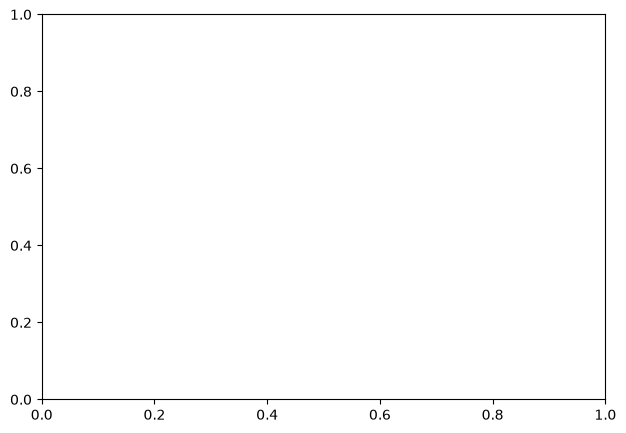

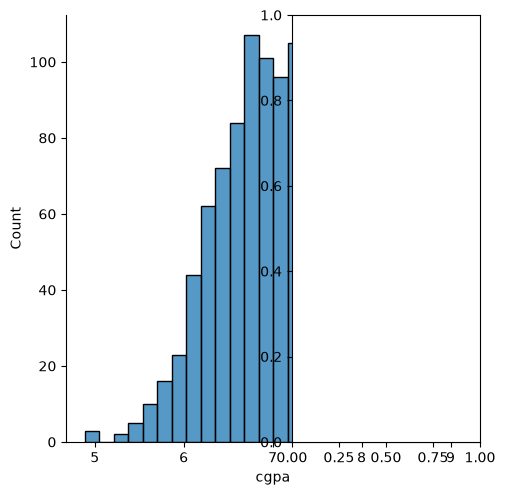

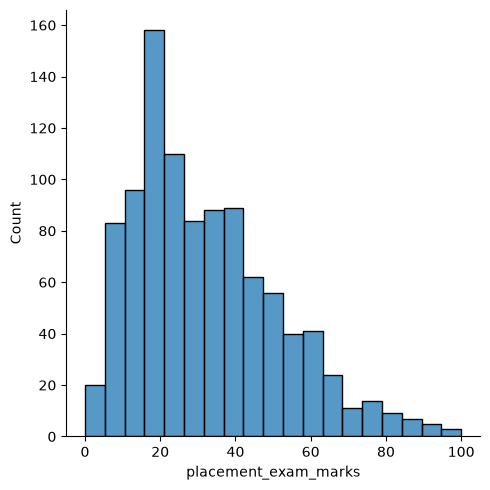

In [20]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.displot(df['cgpa'])

plt.subplot(1,2,2)
sns.displot(df['placement_exam_marks'])

plt.show()

In [21]:
# finding the boundary value
upper_bound = df['cgpa'].mean() + 3* df['cgpa'].std()
lower_bound = df['cgpa'].mean() - 3* df['cgpa'].std()
upper_bound,lower_bound

(np.float64(8.808933625397168), np.float64(5.113546374602832))

In [22]:
#finding the outliers
outliers = df[(df['cgpa'] > upper_bound) | (df['cgpa'] < lower_bound)]
outliers

,cgpa,placement_exam_marks,placed
485,4.92,44.0,1
995,8.87,44.0,1
996,9.12,65.0,1
997,4.89,34.0,0
999,4.90,10.0,1


### Trimming

In [23]:
new_df = df[(df['cgpa'] < upper_bound) & (df['cgpa'] > lower_bound)]
new_df

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
991,7.04,57.0,0
992,6.26,12.0,0
993,6.73,21.0,1
994,6.48,63.0,0


### Capping

In [24]:
# 3 parameters in np.where(condition,if condition true then,if condition false then)

df['cgpa'] = np.where(df['cgpa'] > upper_bound,
    upper_bound,
    np.where(
    df['cgpa'] > lower_bound,
    lower_bound,
    df['cgpa']))

In [25]:
df['cgpa'].describe()

count    1000.000000
mean        5.120307
std         0.165610
min         4.890000
25%         5.113546
50%         5.113546
75%         5.113546
max         8.808934
Name: cgpa, dtype: float64

We can see that the first describe the min and max value is 4.8 and 9.12 and after capping its 4.8 mad 8.8

Its only downside is that its work on normal distribution

## IQR Method

We use this when the data is skwed
<br>
We must know box plot and IQR(InterQuartial Range)<br>
Box plot divide the data into percentiles<br>
like 25 percentile,50,75 and 100<br>
50 percentiles is called median<br><br>
IQR is the difference between Q1 to Q3 that is from 25th percentile to 75th percentile<br>

Minimum = Q1 - 1.5 *IQR<br>
Maximum = Q3 + 1.5 *IQR<br><br>
This whole thing is called IQR Proximity Rule  

In [26]:
df_IQ = pd.read_csv("placement.csv")

In [28]:
df_IQ.sample()

,cgpa,placement_exam_marks,placed
16,6.53,19.0,0


In [31]:
#if value is near to 0 then its normal distributed else skwed
df_IQ.skew()
# here placement_exam_marks is right skwed

cgpa                   -0.014530
placement_exam_marks    0.835642
placed                  0.044077
dtype: float64

In [33]:
df_IQ['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

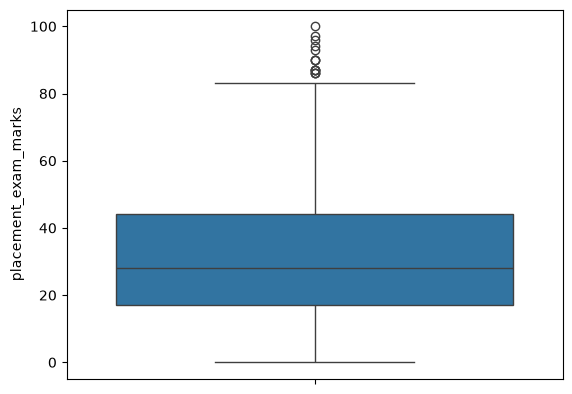

In [34]:
sns.boxplot(df['placement_exam_marks'])

In [36]:
# finding IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)
percentile25,percentile75

(np.float64(17.0), np.float64(44.0))

In [38]:
IQR = percentile75 - percentile25
IQR

np.float64(27.0)

In [40]:
lower_limit = percentile25 - 1.5 * IQR
upper_limit = percentile75 + 1.5 * IQR
lower_limit,upper_limit

(np.float64(-23.5), np.float64(84.5))

In [41]:
# finding Outliers
df[(df['placement_exam_marks'] > upper_limit) | (df['placement_exam_marks']< lower_limit)]

,cgpa,placement_exam_marks,placed
9,5.113546,94.0,1
40,5.113546,86.0,1
61,5.113546,86.0,0
134,5.113546,93.0,0
162,5.113546,90.0,0
283,5.113546,87.0,0
290,5.113546,87.0,0
311,5.113546,87.0,1
324,5.113546,90.0,0
630,5.113546,96.0,1


#### Trimming

In [44]:
# we only use upper limit as there are no outlier on the lower side as the min is 0
new_IQR_df = df[df['placement_exam_marks'] < upper_limit]
new_IQR_df.shape
#here 15 rows are deleted changing the shape of the dataset

(985, 3)

#### Capping

In [45]:
new_df_cap = df_IQ.copy()

new_df_cap['placement_exam_marks'] = np.where(df['placement_exam_marks'] > upper_limit,upper_limit,np.where(new_df_cap['placement_exam_marks'] < lower_limit,lower_limit,new_df_cap['placement_exam_marks']))

In [48]:
new_df_cap['placement_exam_marks'].describe()

count    1000.000000
mean       32.136500
std        18.865419
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max        84.500000
Name: placement_exam_marks, dtype: float64

We can see here that the max value has changed from 100 to 84 due to capping

## Winsorization

Here we set an threshole on the lower limit and upper limit<br>
on lower side we mostly use 1 and on upper side we use 99<br><br>
We can change the values accoeding to need<br>
Once outlier is found we can trim it or cap it <br>
Here capping using percentile is called Winsorization 

In [49]:
import pandas as pd
import numpy as np

In [51]:
df = pd.read_csv("weight-height.csv")
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [52]:
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [53]:
import seaborn as sns

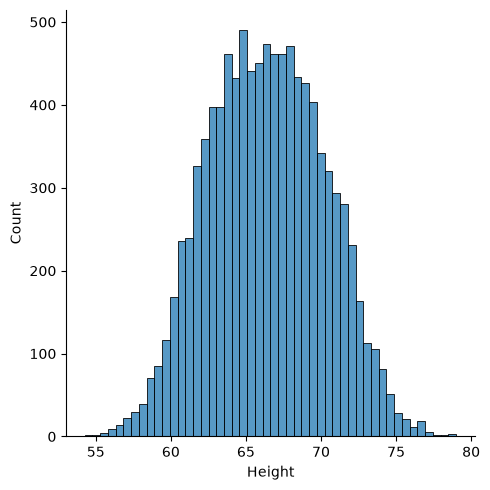

In [66]:
sns.displot(df['Height'])

<Axes: ylabel='Height'>

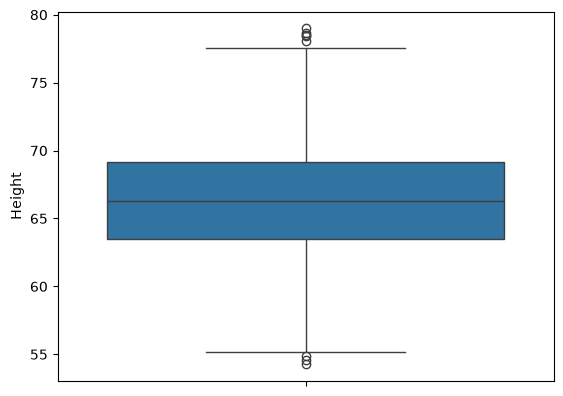

In [55]:
sns.boxplot(df['Height'])

In [58]:
# we will dicide an lower value and upper value and conside outof that values as outliers
upper_thresh = df['Height'].quantile(0.99)
lower_thresh = df['Height'].quantile(0.01)
upper_thresh,lower_thresh
# we have to keep the lower and upper simetric like if the upper is 95 then the lower should be 5 , so what we leave on upper should decide the lower

(np.float64(74.7857900583366), np.float64(58.13441158671655))

In [ ]:
outliers_win = df[(df['Height'] >= 74.78) | (df['Height'] <= 58.13)]

,Gender,Height,Weight
23,Male,75.205974,228.761781
190,Male,76.709835,235.035419
197,Male,75.944460,231.924749
202,Male,75.140821,224.124271
215,Male,74.795375,232.635403
...,...,...,...
9761,Female,56.975279,90.341784
9825,Female,55.979198,85.417534
9895,Female,57.740192,93.652957
9904,Female,57.028857,101.202551


In [61]:
new_win_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [64]:
new_win_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [65]:
new_win_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

### capping --> Winsorization

In [71]:
df_cap = df.copy()

df_cap['Height']=np.where(df['Height']>= upper_thresh,upper_thresh,np.where(df['Height']<= lower_thresh,lower_thresh,df['Height']))

In [73]:
df_cap['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64